In [1]:
2+2

4

In [3]:
import torch
import time

# -----------------------------
# Configuration
# -----------------------------
N = 3200
D = 2048
TOP_K = 10

print(f"Rows      : {N}")
print(f"Embedding : {D}")

# -----------------------------
# Create embeddings
# -----------------------------
t0 = time.perf_counter()

embeddings = torch.randn(N, D, dtype=torch.float32)
query = torch.randn(D, dtype=torch.float32)

t1 = time.perf_counter()

print(f"Creation Time : {(t1-t0)*1000:.3f} ms")

# -----------------------------
# Normalize
# -----------------------------
t0 = time.perf_counter()

embeddings = torch.nn.functional.normalize(
    embeddings,
    p=2,
    dim=1
)

query = torch.nn.functional.normalize(
    query,
    p=2,
    dim=0
)

t1 = time.perf_counter()

print(f"Normalize Time : {(t1-t0)*1000:.3f} ms")

# -----------------------------
# Similarity Search
# -----------------------------
t0 = time.perf_counter()

scores = embeddings @ query

t1 = time.perf_counter()

print(f"Similarity Time : {(t1-t0)*1000:.6f} ms")

# -----------------------------
# Top K
# -----------------------------
t0 = time.perf_counter()

topk_scores, topk_idx = torch.topk(
    scores,
    k=TOP_K
)

t1 = time.perf_counter()

print(f"TopK Time : {(t1-t0)*1000:.6f} ms")

# -----------------------------
# Total Search
# -----------------------------
t0 = time.perf_counter()

scores = embeddings @ query
topk_scores, topk_idx = torch.topk(scores, k=TOP_K)

t1 = time.perf_counter()

print(f"Search Total : {(t1-t0)*1000:.6f} ms")

print("\nTop Results")
for i in range(TOP_K):
    print(
        f"Rank {i+1:2d} | "
        f"Index {topk_idx[i].item():4d} | "
        f"Score {topk_scores[i].item():.4f}"
    )

# -----------------------------
# Hardware Info
# -----------------------------
print("\nPyTorch Info")
print("Torch Version :", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Rows      : 3200
Embedding : 2048
Creation Time : 33.555 ms
Normalize Time : 2.770 ms
Similarity Time : 0.828200 ms
TopK Time : 0.179300 ms
Search Total : 0.828000 ms

Top Results
Rank  1 | Index 1555 | Score 0.0744
Rank  2 | Index 2366 | Score 0.0606
Rank  3 | Index 2914 | Score 0.0605
Rank  4 | Index 2361 | Score 0.0595
Rank  5 | Index 1515 | Score 0.0586
Rank  6 | Index 1019 | Score 0.0585
Rank  7 | Index 2257 | Score 0.0585
Rank  8 | Index 3049 | Score 0.0576
Rank  9 | Index 2279 | Score 0.0574
Rank 10 | Index  809 | Score 0.0573

PyTorch Info
Torch Version : 2.12.0+cu130
CUDA Available: False


z:\alexnet\Alexnet-from-real-scratch\venv\Lib\site-packages\torch\cuda\__init__.py:187: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [3]:
class Value:
    def __init__(self,data, _children=(),_op="",label = ""):
        self.data = data
        self._prev = set(_children)
        self.grad = 0.0
        self._op = _op
        self.label = label
        self._backward = lambda : None
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data,(self,other),"+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __radd__(self, other):
        return self + other
    
    def __pow__(self, other):
        assert isinstance(other, (int,float)), "only supporting int/float powers for now" 
        out = Value((self.data ** other),(self,),f"**{other}")
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * (other ** -1)
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),"tanh")
        def _backward():
            self.grad += (1 - (t ** 2)) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),"exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



In [4]:
a = Value(2.0)
b = Value(4.0)
a.exp()

a - b


Value(data=-2.0)

In [5]:
a = Value(2.0)
a = a + 3
2 * a

Value(data=10.0)

In [6]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label= n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot




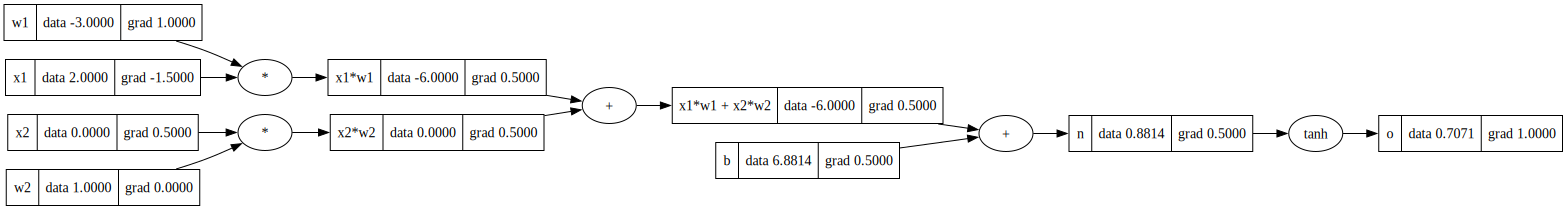

In [7]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)

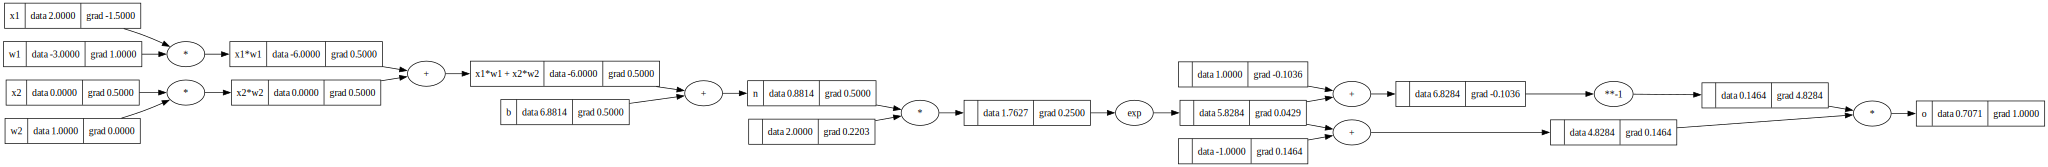

In [8]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1) / (e + 1)

o.label = 'o'

o.backward()

draw_dot(o)

In [9]:
import torch

x1 = torch.Tensor([2.0]).double()
x2 = torch.Tensor([0.0]).double()

w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()

b = torch.Tensor([6.8813735870195432]).double()

# Enable gradient tracking
x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad = True

# Forward pass
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())

# Backward pass
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [341]:
import random

class Neuron:
    
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((w1*x1 for w1,x1 in zip(self.w,x)),self.b)
        out = act.tanh()
        return(out)

    def parameters(self):
        return self.w + [self.b]
    
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    def gradients(self):
        return [p.grad for p in self.parameters()]


In [342]:
x = [2.0,5.0,4.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.9215943698917052)

In [343]:
n.parameters()

[Value(data=-0.5729784779833658),
 Value(data=-0.43395409751846814),
 Value(data=-0.043852547246006957),
 Value(data=-0.15355281875594962),
 Value(data=0.7506061752130324),
 Value(data=-0.5831924663873769),
 Value(data=0.14477749913523996),
 Value(data=0.024995272604188434),
 Value(data=0.5847347257647502),
 Value(data=-0.4424485710237158),
 Value(data=0.7130439223762199),
 Value(data=-0.011793266264610525),
 Value(data=0.7369564984554287),
 Value(data=0.7167486609950495),
 Value(data=-0.09207887476501853),
 Value(data=0.8484944032014712),
 Value(data=0.32268593910828547),
 Value(data=0.30449538403947507),
 Value(data=-0.7614668302965968),
 Value(data=-0.7611407593265183),
 Value(data=-0.7917804259257755),
 Value(data=-0.9312850590830828),
 Value(data=0.5168048377501724),
 Value(data=-0.04657384432810696),
 Value(data=-0.26102555298439833),
 Value(data=0.6145059314915109),
 Value(data=0.1358624480425974),
 Value(data=0.11910124730223859),
 Value(data=0.5507140076831758),
 Value(data=-0

In [344]:
xs = [
    [1.0,3.0,-6.0],
    [2.0,-6.0,1.0],
    [-1.0,5.0,8.0],
    [5.0,-2.0,4.0]
]

ys = [-1.0,1.0,-1.0,1.0]
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.7959960099139622),
 Value(data=-0.8412025074974252),
 Value(data=-0.915336937523268),
 Value(data=-0.9316833268138618)]

In [345]:
for k in range(100+1):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)** 2 for ygt,yout in zip(ys,ypred))

    #zero_grad
    for p in n.parameters():
        p.grad = 0.0
    
    #backward pass
    loss.backward()

    #gradient_descent
    for p in n.parameters():
        p.data += -0.05 * p.grad

    if k % 10 == 0:
        print(k,loss.data)

0 7.1702126108244375
10 0.3496764468067335
20 0.10614379413458744
30 0.05741064807314966
40 0.038099715078045826
50 0.02805724750997584
60 0.021999991867424316
70 0.017987453718471443
80 0.015151850902757148
90 0.013050912229424321
100 0.0114370925087243


In [346]:
ypred

[Value(data=-0.970416792823645),
 Value(data=0.9840054220390205),
 Value(data=-0.9324879374316836),
 Value(data=0.92418297522649)]